# Introdução

A Uber é uma plataforma que utiliza tecnologia e dados para conectar motoristas e passageiros, gerando um grande volume de informações sobre corridas, horários e padrões de uso.

## **Objetivos**

Este notebook tem como objetivo analisar o dataset ncr_ride_bookings.csv, que reúne informações sobre corridas realizadas utilizando a plataforma Uber.
A análise desses dados a partir de uma Análise Exploratória de Dados (EAD)permite compreender padrões de uso da Uber, entender as características das corridas e identificar oportunidades de otimização por meio de técnicas de Inteligência Artificial.

# Importação de Bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para o desenvolvimento da análise. Elas incluem ferramentas para manipulação e análise de dados (pandas), computação numérica (numpy), visualização gráfica e dados estatísticos (matplotlib e seaborn) e construção de modelos de aprendizado de máquina (scikit-learn).

Essa organização é importante para garantir que todo o notebook seja executado de forma clara, padronizada e reproduzível.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.cluster import DBSCAN, KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, silhouette_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Carregamento e Entendimento dos Dados


Este notebook analisa o dataset **NCR Ride Bookings**, que reúne informações sobre as corridas realizadas utilizando a plataforma Uber.


Inicialmente, é realizado o carregamento deste arquivo, que será a base de todo o estudo.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/evelynkleinenf-cloud/uber_eda/refs/heads/main/dados/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


O dataset utilizado apresenta as seguintes variáveis, em 21 colunas:

*   **Date**: A data em que a corrida foi agendada ou iniciada.
*   **Time**: O horário em que a corrida foi agendada ou iniciada.
*   **Booking ID**: Um identificador único para cada reserva de corrida.
*   **Booking Status**: O status atual da reserva da corrida (ex: 'Completed', 'No Driver Found', 'Incomplete', 'Cancelled by Customer', 'Cancelled by Driver').
*   **Customer ID**: Um identificador único para cada cliente.
*   **Vehicle Type**: O tipo de veículo solicitado para a corrida (ex: 'eBike', 'Go Sedan', 'Auto', 'Premier Sedan', 'Bike').
*   **Pickup Location**: O local de partida da corrida.
*   **Drop Location**: O local de destino da corrida.
*   **Avg VTAT (Average Vehicle Arrival Time)**: O tempo médio estimado para a chegada do veículo ao local de embarque.
*   **Avg CTAT (Average Customer Arrival Time)**: O tempo médio estimado para o cliente chegar ao local de embarque ou para o início da corrida após a chegada do veículo.
*   **Cancelled Rides by Customer**: Indica se a corrida foi cancelada pelo cliente (1 se sim, 0 se não, ou NaN se não se aplica).
*   **Reason for cancelling by Customer**: O motivo fornecido pelo cliente para cancelar a corrida.
*   **Cancelled Rides by Driver**: Indica se a corrida foi cancelada pelo motorista (1 se sim, 0 se não, ou NaN se não se aplica).
*   **Driver Cancellation Reason**: O motivo fornecido pelo motorista para cancelar a corrida.
*   **Incomplete Rides**: Indica se a corrida foi incompleta (1 se sim, 0 se não, ou NaN se não se aplica).
*   **Incomplete Rides Reason**: O motivo pelo qual a corrida foi considerada incompleta.
*   **Booking Value**: O valor total da corrida.
*   **Ride Distance**: A distância percorrida na corrida, em quilômetros.
*   **Driver Ratings**: A avaliação dada ao motorista pelo cliente (em uma escala de 0 a 5).
*   **Customer Rating**: A avaliação dada ao cliente pelo motorista (em uma escala de 0 a 5).
*   **Payment Method**: O método de pagamento utilizado para a corrida (ex: 'UPI', 'Debit Card').

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

Observamos que o dataset apresenta 150.000 linhas de dados, identificamos o tipo de cada coluna das variáveis e que algumas apresentam valores ausentes (como as colunas Avg VTAT, Avg CTAT, Booking Value, Ride Distance, Driver Ratings, Customer Rating, além das colunas que indicam um evento específico, como Cancelled Rides by Customer, Cancelled Rides by Driver e Incomplete Rides).

In [4]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000



*   **Avg VTAT (Average Vehicle Arrival Time):** O tempo médio de chegada do veículo é de aproximadamente 8.46 minutos, com um desvio padrão de 3.77 minutos, variando de 2 a 20 minutos. Isso mostra que, em geral, os veículos chegam em um tempo razoável, mas há variabilidade.
*   **Avg CTAT (Average Customer Arrival Time):** O tempo médio para o cliente chegar ou a corrida iniciar após a chegada do veículo é de cerca de 29.15 minutos, com um desvio padrão maior de 8.9 minutos, variando de 10 a 45 minutos. Isso sugere uma maior variação no tempo que o cliente leva para iniciar a viagem.
*   **Booking Value e Ride Distance:** Para as corridas registradas, o valor médio é de 508,30 e a distância média é de 24.64 km. O valor máximo de uma corrida é de 4277,00 e a distância máxima é de 50 km, indicando uma amplitude considerável nesses dados.
*   **Driver Ratings e Customer Rating:** As avaliações de motoristas e clientes variam de 3.0 a 5.0. A média das avaliações dos motoristas é de 4.23, e a dos clientes é de 4.40. O desvio padrão relativamente baixo (cerca de 0.4) indica que as avaliações tendem a ser consistentes e geralmente altas, sugerindo uma boa qualidade geral do serviço.


# Limpeza de Dados + Feature Engineering

A etapa de **Limpeza de Dados** tem como finalidade corrigir inconsistências e preparar a base para análises mais confiáveis.
Esse processo é essencial porque a qualidade dos resultados depende diretamente da qualidade dos dados utilizados.

Utilizando **Feature Engineering**, são criadas novas variáveis a partir das informações já existentes no dataset. O objetivo é enriquecer a base com atributos que facilitem a interpretação dos dados e aumentem o potencial analítico da modelagem.


## **Tratamento de Valores Ausentes (Missing Values):**

Nesta etapa, os valores ausentes são analisados de forma contextual, considerando que a ausência de informação nem sempre representa erro. Em algumas colunas, os valores nulos indicam apenas que determinado evento não ocorreu; em outras, a ausência foi mantida por fazer parte da própria lógica do processo operacional.






Primeiramente, é feita a identificação da quantidade de valores ausentes em cada coluna.



In [5]:
print(df.isnull().sum())

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64


**Cancelled Rides by Customer, Cancelled Rides by Driver, Incomplete Rides**

Os valores ausentes são substituídos por zero, pois a ausência de registro indica que o evento correspondente não ocorreu, como cancelamentos ou corridas incompletas.

In [6]:
colunas_evento = ['Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides']
for col in colunas_evento:
    df[col] = df[col].fillna(0)

Em seguida, é realizada uma verificação para confirmar que essas colunas passaram a conter apenas valores binários.



In [7]:
print(df['Cancelled Rides by Customer'].unique())
print(df['Cancelled Rides by Driver'].unique())
print(df['Incomplete Rides'].unique())

[0. 1.]
[0. 1.]
[0. 1.]


**Driver Ratings, Customer Rating, Booking Value, Ride Distance, Payment Method, Avg CTAT, Avg VTAT**

Os valores ausentes são mantidos, pois sua ausência pode estar associada à própria natureza do status da corrida, e não necessariamente a um erro no dataset.



In [8]:
colunas_manter_nulos = ['Driver Ratings','Customer Rating','Booking Value','Ride Distance','Payment Method','Avg CTAT','Avg VTAT']
print(df[colunas_manter_nulos].isnull().sum())

Driver Ratings     57000
Customer Rating    57000
Booking Value      48000
Ride Distance      48000
Payment Method     48000
Avg CTAT           48000
Avg VTAT           10500
dtype: int64


**Reason for cancelling by Customer, Driver Cancellation Reason, Incomplete Rides Reason**

Os valores ausentes são mantidos, pois essas informações só são preenchidas quando o respectivo evento ocorre. Dessa forma, os nulos possuem significado contextual e não devem ser tratados como erro.

In [9]:
colunas_motivo = ['Reason for cancelling by Customer','Driver Cancellation Reason','Incomplete Rides Reason']
print(df[colunas_motivo].isnull().sum())

Reason for cancelling by Customer    139500
Driver Cancellation Reason           123000
Incomplete Rides Reason              141000
dtype: int64


## **Tratamento de Duplicatas:**

Nesta etapa, é verificada a existência de registros duplicados no dataset, uma vez que a repetição de linhas pode comprometer a qualidade da análise e gerar distorções nos resultados. A identificação dessas duplicatas é importante para garantir maior consistência, confiabilidade e integridade na base de dados.

In [10]:
num_duplicatas = df.duplicated().sum()
print(f'Número de linhas duplicadas no dataset: {num_duplicatas}')

Número de linhas duplicadas no dataset: 0


O resultado igual a 0 indica que não foram encontrados registros duplicados no dataset. Isso mostra que, nesse aspecto, a base já apresenta consistência e não exige remoção de linhas repetidas.

## **Correção de Tipos de Dados:**

Nesta etapa, são ajustados os tipos das variáveis para garantir que cada coluna esteja no formato mais adequado para análise. Esse processo é importante para permitir operações corretas com datas, horários e valores numéricos, evitando erros nas etapas seguintes.



In [11]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

Em seguida, as colunas numéricas são convertidas para um formato apropriado, assegurando que cálculos estatísticos e análises quantitativas possam ser realizados corretamente.



In [12]:
colunas_numericas = ['Avg VTAT','Avg CTAT','Booking Value','Ride Distance','Driver Ratings','Customer Rating']
for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Por fim, é feita uma verificação inicial da base após as conversões, com o objetivo de confirmar se os dados estão devidamente ajustados.

In [13]:
df.head()
print(df.dtypes)

Date                                 datetime64[ns]
Time                                 datetime64[ns]
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64
Customer Rat

## **Correção de Erros e Inconsistências (Data Consistency):**

Após a correção dos tipos de dados, são analisadas inconsistências que podem comprometer a confiabilidade da base. Entre elas, destacam-se valores inválidos, como distâncias e valores negativos, além de avaliações fora da escala esperada. As colunas textuais também são padronizadas para remover espaços indevidos, reduzindo problemas de formatação inconsistente entre categorias.







In [14]:
colunas_texto = ['Booking Status','Pickup Location','Drop Location','Reason for cancelling by Customer','Driver Cancellation Reason','Incomplete Rides Reason', 'Payment Method']
for col in colunas_texto: df[col] = df[col].astype(str).str.strip()

Em seguida, são aplicadas regras simples de consistência para tratar valores incompatíveis com o contexto da análise.



In [15]:
df['Ride Distance'] = df['Ride Distance'].where(df['Ride Distance'] >= 0)
df['Booking Value'] = df['Booking Value'].where(df['Booking Value'] >= 0)
df['Driver Ratings'] = df['Driver Ratings'].where(df['Driver Ratings'].between(0, 5) | df['Driver Ratings'].isna())
df['Customer Rating'] = df['Customer Rating'].where(df['Customer Rating'].between(0, 5) | df['Customer Rating'].isna())

Depois disso, é feita uma verificação para confirmar que os valores inválidos foram tratados corretamente.



In [16]:
print('Ride Distance < 0:', (df['Ride Distance'] < 0).sum())
print('Booking Value < 0:', (df['Booking Value'] < 0).sum())
print('Driver Ratings fora de 0-5:', ((df['Driver Ratings'] < 0) | (df['Driver Ratings'] > 5)).sum())
print('Customer Rating fora de 0-5:', ((df['Customer Rating'] < 0) | (df['Customer Rating'] > 5)).sum())

Ride Distance < 0: 0
Booking Value < 0: 0
Driver Ratings fora de 0-5: 0
Customer Rating fora de 0-5: 0


## **Tratamento de Outliers**

Além das inconsistências lógicas, também são investigados valores extremos nas principais variáveis numéricas. Essa análise é importante porque outliers podem distorcer estatísticas, visualizações e modelos preditivos.




A identificação inicial é feita por meio de boxplots, permitindo visualizar a distribuição dos dados e a presença de valores extremos.



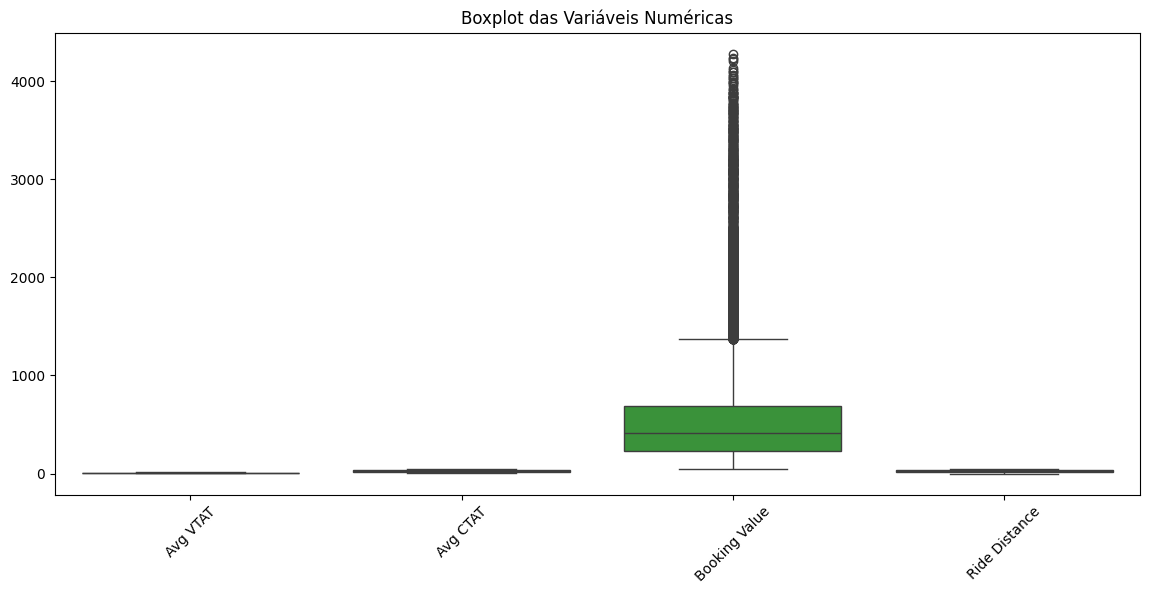

In [17]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance']])
plt.title('Boxplot das Variáveis Numéricas')
plt.xticks(rotation=45)
plt.show()

O boxplot mostra a distribuição das principais variáveis numéricas do dataset e evidencia a presença de valores extremos, especialmente na coluna Booking Value.

Observa-se que essa variável apresenta maior dispersão e uma quantidade significativa de outliers, enquanto Avg VTAT, Avg CTAT e Ride Distance possuem comportamento mais concentrado.

Essa análise é importante para identificar a necessidade de tratamento dos valores extremos antes das etapas seguintes.

Em seguida, é utilizada a regra do intervalo interquartil (IQR) para quantificar a presença de outliers em cada variável.

In [18]:
colunas_outliers = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance']
print('Quantidade de outliers por coluna:')
for col in colunas_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f'{col}: {outliers.shape[0]}')

Quantidade de outliers por coluna:
Avg VTAT: 0
Avg CTAT: 0
Booking Value: 3435
Ride Distance: 0


Os resultados indicam que a coluna Booking Value concentra valores extremos relevantes, enquanto Avg VTAT, Avg CTAT e Ride Distance não apresentaram outliers segundo esse critério.

Para evitar a perda excessiva de dados, os valores extremos são tratados com a técnica de clipping, limitando-os a faixas estatisticamente aceitáveis em vez de remover registros da base.



In [19]:
for col in colunas_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    df[col] = df[col].clip(limite_inferior, limite_superior)

Por fim, o tratamento de outliers contribui para tornar a base mais robusta, preservando os registros e reduzindo o impacto de valores extremos sobre a análise exploratória e os modelos de inteligência artificial.



## **Validação Final da Limpeza**

Após as etapas de correção e tratamento, é recomendável realizar uma verificação final para confirmar que a base ficou consistente e adequada para as próximas análises.

In [20]:
print(df.dtypes)
print(df.isnull().sum())
print(df[['Ride Distance', 'Booking Value', 'Driver Ratings', 'Customer Rating']].describe())

Date                                 datetime64[ns]
Time                                 datetime64[ns]
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64
Customer Rat

## **Feature Engineering:**

Nesta etapa, são criadas novas variáveis a partir das colunas originais do dataset, com o objetivo de enriquecer a base e facilitar análises. A criação desses atributos permite representar melhor padrões temporais e operacionais das corridas.




### **Extração da Hora**

Primeiramente, é extraída apenas a hora da coluna Time, desconsiderando minutos e segundos. Essa transformação permite analisar em quais períodos do dia há maior concentração de corridas.

In [21]:
df['hora'] = df['Time'].dt.hour
print(df['hora'].value_counts())

hora
18    12397
19    11047
17    11044
16     9633
20     9630
10     9577
11     8390
9      8234
15     8202
21     8103
14     7031
12     7006
8      6861
13     5470
7      5450
22     5441
6      4160
5      2786
23     2762
3      1383
0      1373
1      1360
2      1339
4      1321
Name: count, dtype: int64


### **Criação da Variável de Dia Útil e Final de Semana**

Em seguida, é criada uma variável binária a partir da coluna Date para diferenciar dias úteis e finais de semana. É atribuído valor 1 para corridas realizadas de segunda a sexta-feira e valor 0 para corridas realizadas aos sábados e domingos.

In [22]:
df['dia_semana'] = df['Date'].dt.dayofweek.apply(lambda x: 1 if x < 5 else 0)
print(df['dia_semana'].value_counts())

dia_semana
1    107060
0     42940
Name: count, dtype: int64


### **Preparação de uma Base Mais Enxuta para Análise**


Após a criação das novas variáveis, é preparada uma versão mais enxuta do dataset para facilitar as etapas de análise. Nessa versão, são removidas colunas identificadoras e variáveis temporais originais que já foram transformadas em novos atributos.

In [23]:
df_uber = df.copy()
df_uber = df_uber.drop(columns=['Booking ID', 'Customer ID', 'Date', 'Time'])
df_uber.head()

,Booking Status,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,hora,dia_semana
0,No Driver Found,eBike,Palam Vihar,Jhilmil,NaN,NaN,0.0,nan,0.0,nan,0.0,nan,NaN,NaN,NaN,NaN,nan,12,0
1,Incomplete,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0.0,nan,0.0,nan,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,18,1
2,Completed,Auto,Khandsa,Malviya Nagar,13.4,25.8,0.0,nan,0.0,nan,0.0,nan,627.0,13.58,4.9,4.9,Debit Card,8,1
3,Completed,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0.0,nan,0.0,nan,0.0,nan,416.0,34.02,4.6,5.0,UPI,17,1
4,Completed,Bike,Ghitorni Village,Khan Market,5.3,19.6,0.0,nan,0.0,nan,0.0,nan,737.0,48.21,4.1,4.3,UPI,22,1


# Análise Exploratória de Dados

Nesta etapa, são realizadas análises gráficas e estatísticas com o objetivo de identificar padrões, distribuições e relações importantes entre as variáveis do dataset. A análise exploratória permite compreender melhor o comportamento das corridas e extrair informações relevantes para interpretação dos dados.

## Distribuição de Corridas Concluídas e Não Concluídas

Inicialmente, é analisada a distribuição entre corridas concluídas e não concluídas. Para isso, é criada uma variável binária a partir da coluna Booking Status, permitindo visualizar de forma mais clara a proporção entre esses dois grupos.




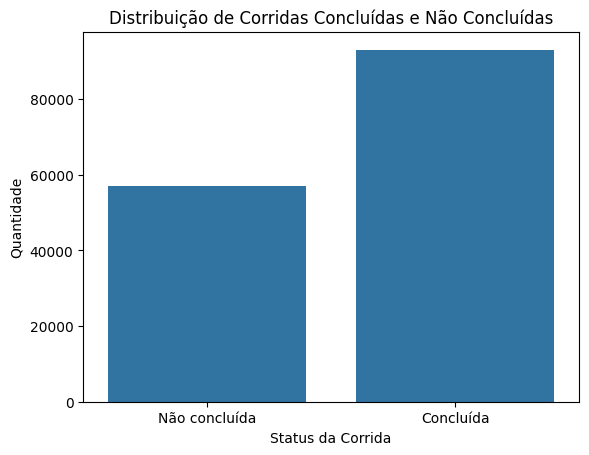

In [24]:
df_uber['status_binario'] = df_uber['Booking Status'].apply(lambda x: 1 if str(x).strip().lower() == 'completed' else 0)
sns.countplot(data=df_uber, x='status_binario')
plt.title('Distribuição de Corridas Concluídas e Não Concluídas')
plt.xlabel('Status da Corrida')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Não concluída', 'Concluída'])
plt.show()

O gráfico mostra a distribuição das corridas concluídas e não concluídas no dataset. Observa-se que a quantidade de corridas concluídas é superior à de corridas não concluídas, indicando que a maior parte das viagens registradas na base foi finalizada com sucesso.

## Distribuição do Valor das Corridas

Em seguida, é analisada a distribuição dos valores das corridas, permitindo observar a concentração das tarifas e a possível presença de assimetrias ou valores extremos.


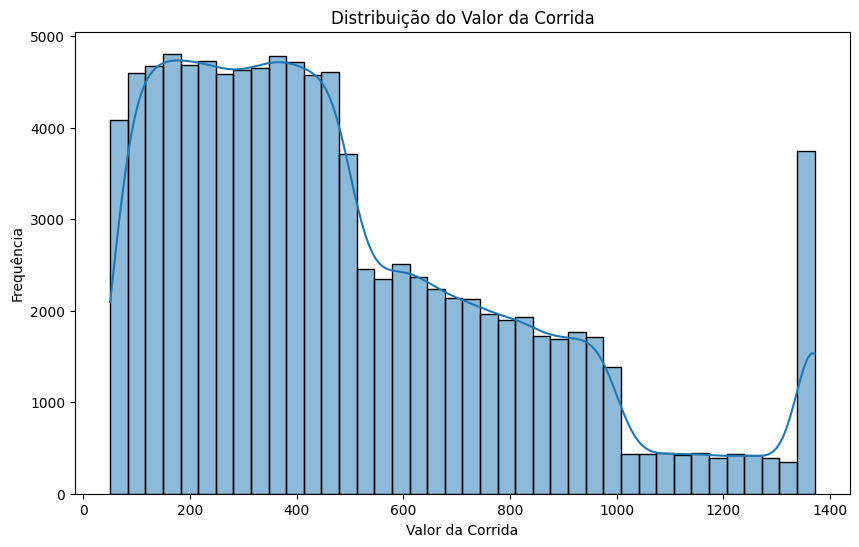

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_uber, x='Booking Value', bins=40, kde=True)
plt.title('Distribuição do Valor da Corrida')
plt.xlabel('Valor da Corrida')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição dos valores das corridas no dataset. Observa-se maior concentração de corridas em faixas intermediárias de preço, enquanto valores mais altos aparecem com menor frequência, indicando uma distribuição assimétrica com presença de corridas de maior valor em menor quantidade.

## Distribuição e Comportamento da Distância das Corridas


Nesta subseção, é analisada a variável Ride Distance com o objetivo de compreender como as distâncias se distribuem no dataset e como se comportam em diferentes situações operacionais. Essa análise permite identificar o perfil predominante dos deslocamentos e verificar diferenças entre corridas efetivamente realizadas.



Inicialmente, é observado o comportamento geral da distância das corridas por meio de um histograma, permitindo visualizar a frequência dos diferentes intervalos de distância registrados na base.



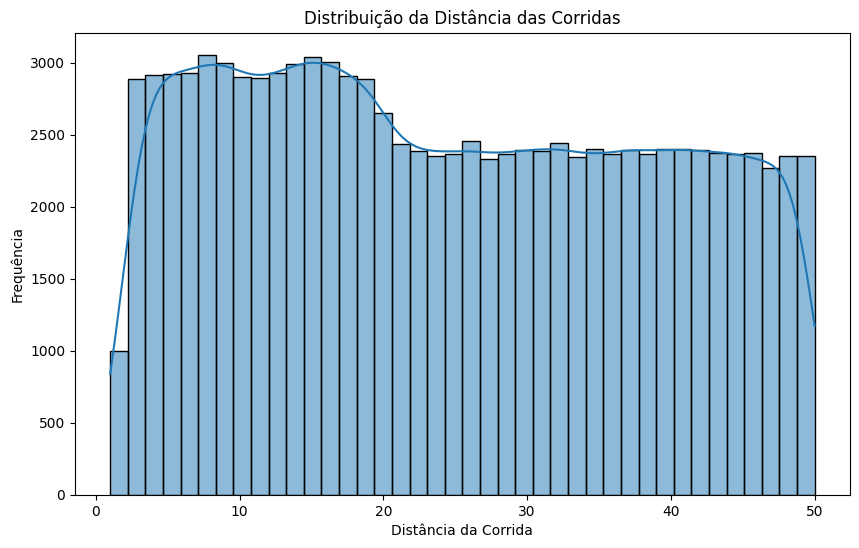

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_uber, x='Ride Distance', bins=40, kde=True)
plt.title('Distribuição da Distância das Corridas')
plt.xlabel('Distância da Corrida')
plt.ylabel('Frequência')
plt.show()

O histograma mostra que as corridas estão distribuídas em diferentes faixas de distância, com maior concentração em percursos curtos e médios. Isso indica que boa parte das viagens registradas no dataset corresponde a deslocamentos de extensão moderada, embora também existam corridas mais longas ao longo da base.

Em seguida, é calculada a distância média apenas para corridas concluídas e incompletas, uma vez que esses status são os que fazem mais sentido para comparação da distância percorrida. Corridas canceladas e casos sem motorista encontrado foram desconsiderados, pois nessas situações a distância tende a ser nula ou não representativa.



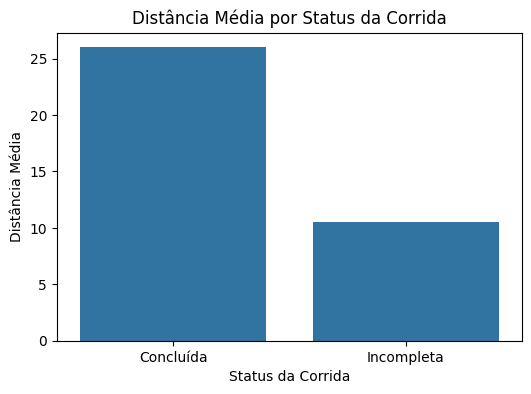

In [27]:
distancia_media_status = df_uber[df_uber['Booking Status'].isin(['Completed', 'Incomplete'])].groupby('Booking Status', dropna=False)['Ride Distance'].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=distancia_media_status.index, y=distancia_media_status.values)
plt.title('Distância Média por Status da Corrida')
plt.xlabel('Status da Corrida')
plt.ylabel('Distância Média')
plt.xticks([0, 1], ['Concluída', 'Incompleta'], rotation=0)
plt.show()

O gráfico mostra que corridas concluídas apresentam distância média superior às corridas incompletas. Esse resultado é coerente, pois viagens finalizadas tendem a percorrer trajetos mais longos, enquanto corridas incompletas podem ter sido interrompidas antes de atingir a distância prevista.



## Análise das Corridas por Horário

Nesta subseção, é analisada a distribuição das corridas ao longo das horas do dia, com o objetivo de identificar os períodos de maior demanda e observar como os diferentes status se comportam em cada horário. Essa análise é importante para compreender padrões temporais da operação e destacar momentos de maior concentração de corridas concluídas, canceladas ou incompletas.





Com a variável hora, é possível observar em quais momentos do dia ocorre maior volume de corridas. Essa análise ajuda a identificar padrões temporais de demanda.

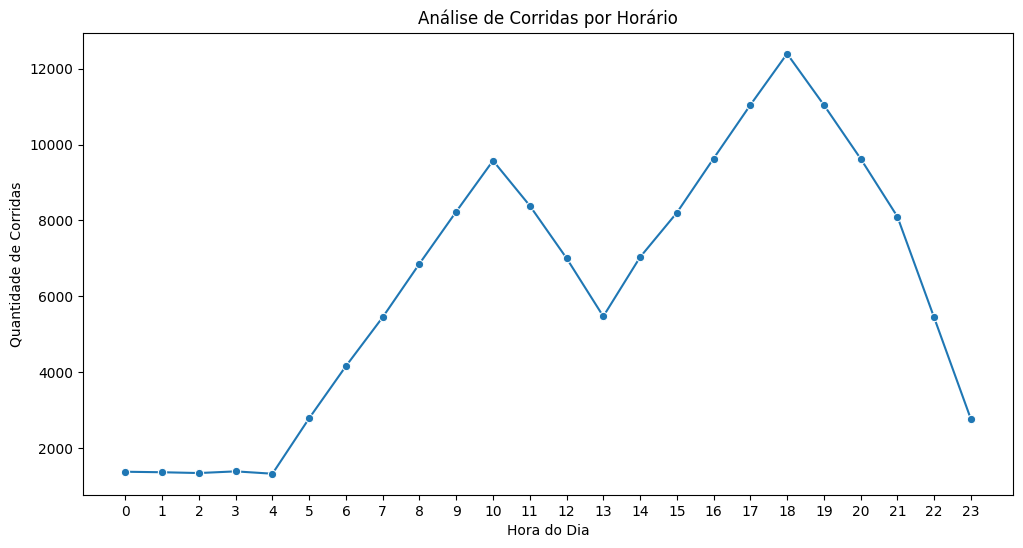

In [28]:
corridas_por_hora = df_uber['hora'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=corridas_por_hora.index, y=corridas_por_hora.values, marker='o')
plt.title('Análise de Corridas por Horário')
plt.xlabel('Hora do Dia')
plt.ylabel('Quantidade de Corridas')
plt.xticks(range(24))
plt.show()

Observa-se que a demanda é menor durante a madrugada, cresce progressivamente ao longo da manhã e da tarde, e atinge seu pico no início da noite, indicando horários de maior movimento na base analisada.

Nesta análise, buscou-se observar como os diferentes status das corridas se distribuem ao longo das horas do dia. O objetivo é identificar em quais horários há maior concentração de corridas concluídas, canceladas, incompletas ou sem motorista encontrado, permitindo uma visão mais detalhada do comportamento operacional da plataforma.


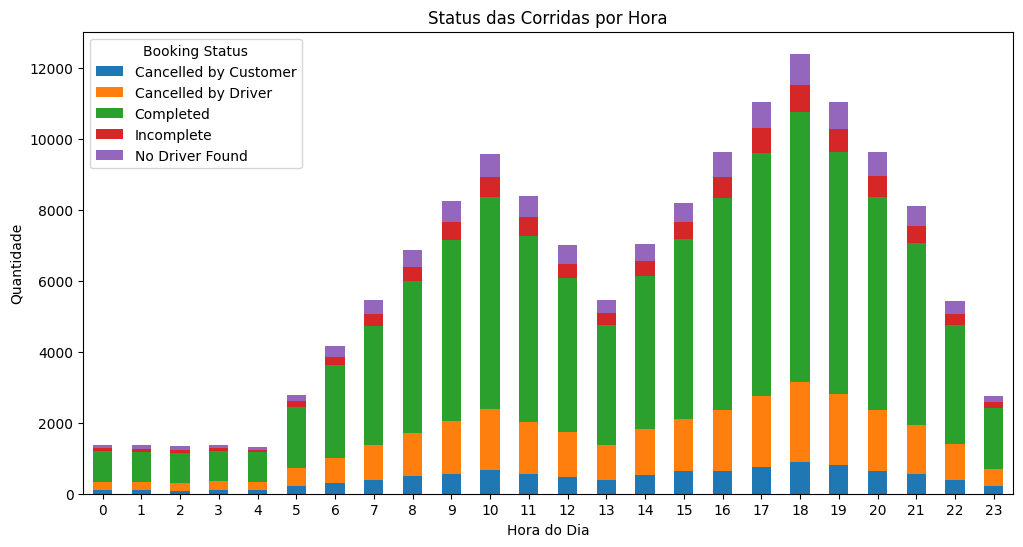

In [29]:
status_por_hora = pd.crosstab(df_uber['hora'], df_uber['Booking Status'])
ax = status_por_hora.plot(kind='bar', stacked=True, figsize=(12, 6))
ax.set_title('Status das Corridas por Hora')
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Quantidade')
ax.tick_params(axis='x', rotation=0)
plt.show()

O gráfico mostra que o volume total de corridas aumenta ao longo do dia, com maior concentração entre o final da manhã e o início da noite. Observa-se que as corridas concluídas predominam em todos os horários, mas os demais status também acompanham o aumento do fluxo, indicando que períodos de maior demanda concentram não apenas mais corridas finalizadas, mas também maior ocorrência de cancelamentos, incompletudes e casos sem motorista disponível.

## Distribuição das Corridas por Tipo de Dia

A distribuição das corridas entre dias úteis e fins de semana  é analisada. Essa comparação ajuda a entender se a demanda da plataforma se concentra mais na rotina semanal ou em períodos de lazer e deslocamentos típicos do final de semana.


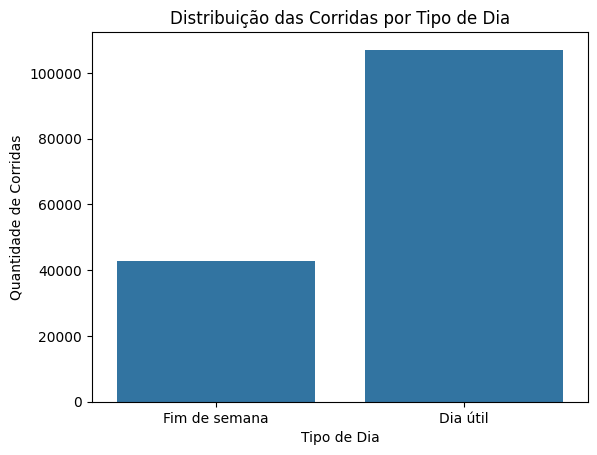

In [30]:
sns.countplot(data=df_uber, x='dia_semana')
plt.title('Distribuição das Corridas por Tipo de Dia')
plt.xlabel('Tipo de Dia')
plt.ylabel('Quantidade de Corridas')
plt.xticks([0, 1], ['Fim de semana', 'Dia útil'])
plt.show()

O gráfico mostra que a quantidade de corridas em dias úteis é significativamente maior do que em fins de semana. Esse resultado sugere que a maior parte da demanda registrada no dataset está associada à rotina diária de deslocamentos, como trabalho, estudo e atividades recorrentes.


## Relação entre Distância e Valor da Corrida

Nesta subseção, é analisada a relação entre a distância percorrida e o valor cobrado por corrida. O objetivo é verificar como essas duas variáveis se comportam em conjunto, identificando padrões de concentração, dispersão e variação dos preços conforme o aumento da distância.



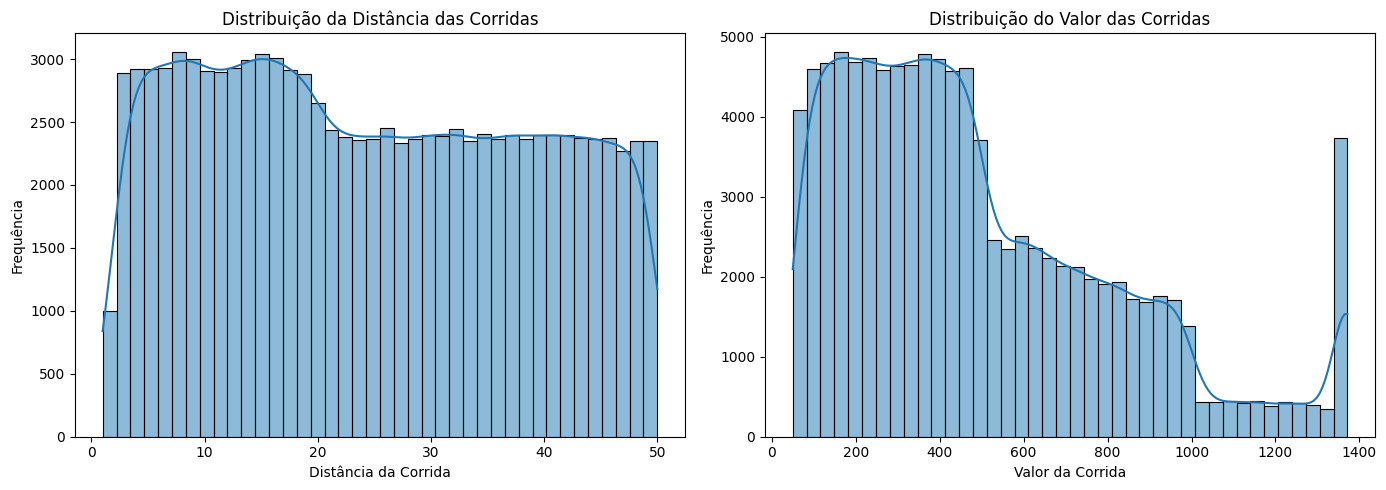

In [31]:
# Distribuição da Distância das Corridas + Distribuição do Valor das Corridas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_uber, x='Ride Distance', bins=40, kde=True, ax=axes[0])
axes[0].set_title('Distribuição da Distância das Corridas')
axes[0].set_xlabel('Distância da Corrida')
axes[0].set_ylabel('Frequência')
sns.histplot(data=df_uber, x='Booking Value', bins=40, kde=True, ax=axes[1])
axes[1].set_title('Distribuição do Valor das Corridas')
axes[1].set_xlabel('Valor da Corrida')
axes[1].set_ylabel('Frequência')
plt.tight_layout()
plt.show()

Como o dataset possui grande volume de registros, é utilizado inicialmente um gráfico do tipo hexbin, que facilita a visualização da concentração de corridas em diferentes combinações de distância e valor. Esse tipo de gráfico é útil para identificar regiões com maior densidade de observações sem sobreposição excessiva de pontos.

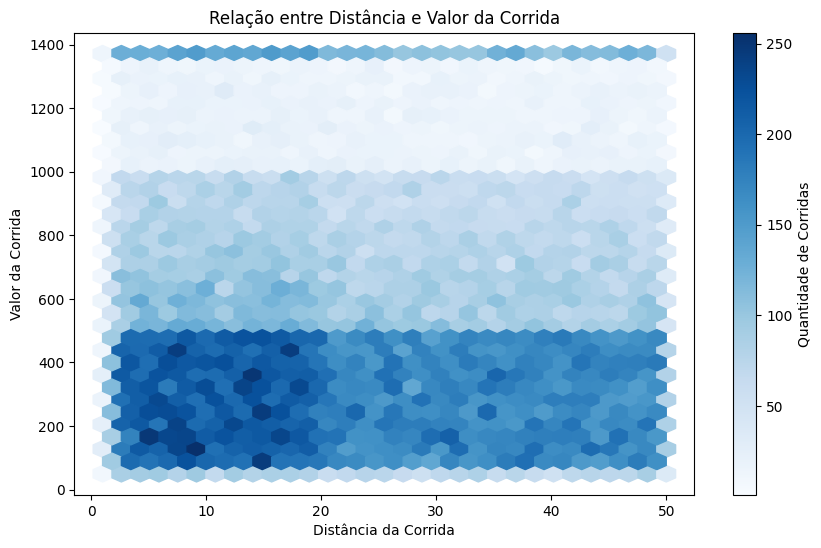

In [32]:
plt.figure(figsize=(10, 6))
plt.hexbin(df_uber['Ride Distance'], df_uber['Booking Value'], gridsize=30, cmap='Blues')
plt.colorbar(label='Quantidade de Corridas')
plt.title('Relação entre Distância e Valor da Corrida')
plt.xlabel('Distância da Corrida')
plt.ylabel('Valor da Corrida')
plt.show()

O gráfico mostra maior concentração de corridas em faixas intermediárias de valor, distribuídas ao longo de diferentes distâncias. Isso indica que, embora exista relação entre distância e preço, a precificação não depende exclusivamente da distância, sugerindo influência de outros fatores operacionais na definição do valor da corrida.

Para complementar a análise, é construído um boxplot com o valor da corrida distribuído por faixas de distância. Essa visualização permite comparar medianas, dispersão e presença de valores extremos em cada intervalo de distância.


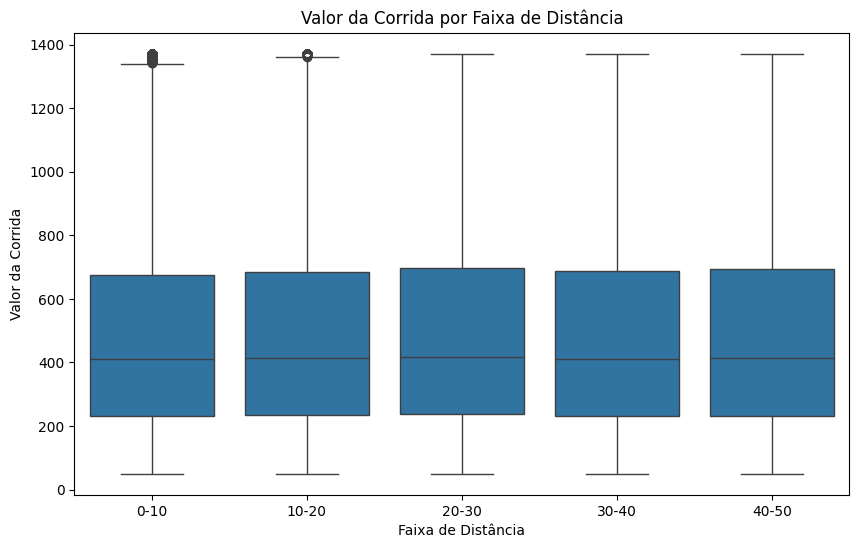

In [33]:
df_uber['faixa_distancia'] = pd.cut(df_uber['Ride Distance'],bins=[0, 10, 20, 30, 40, 50],labels=['0-10', '10-20', '20-30', '30-40', '40-50'])
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_uber, x='faixa_distancia', y='Booking Value')
plt.title('Valor da Corrida por Faixa de Distância')
plt.xlabel('Faixa de Distância')
plt.ylabel('Valor da Corrida')
plt.show()

O boxplot indica que o valor das corridas tende a manter comportamento relativamente semelhante entre as faixas de distância, embora com variações na dispersão e presença de outliers em todos os grupos. Esse resultado reforça a ideia de que a distância influencia o valor da corrida, mas não é o único fator determinante na precificação.

## Relação entre Status da Corrida e Eventos Operacionais

Nesta subseção, é analisada a relação entre os diferentes status das corridas e eventos operacionais relevantes, como cancelamentos pelo cliente, cancelamentos pelo motorista e corridas incompletas. Essa análise ajuda a entender como esses eventos se distribuem dentro dos diferentes resultados registrados na base.



Inicialmente,  observa-se como os principais eventos operacionais aparecem em cada status de corrida. Para isso, são consideradas as colunas binárias relacionadas a cancelamentos pelo cliente, cancelamentos pelo motorista e corridas incompletas.



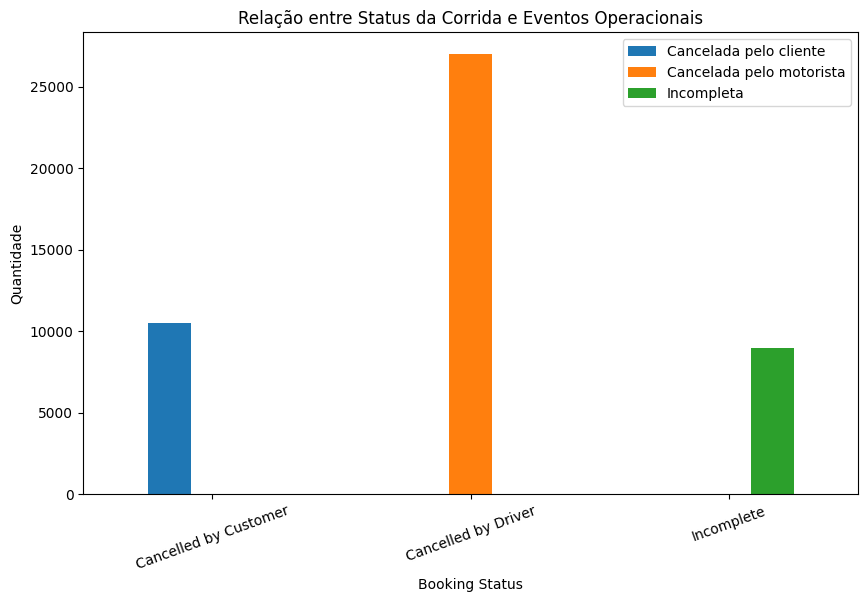

In [34]:
colunas_evento = ['Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides']
relacao_status = df_uber[~df_uber['Booking Status'].isin(['Completed', 'No Driver Found'])].groupby('Booking Status')[colunas_evento].sum()
relacao_status.plot(kind='bar', figsize=(10, 6))
plt.title('Relação entre Status da Corrida e Eventos Operacionais')
plt.xlabel('Booking Status')
plt.ylabel('Quantidade')
plt.xticks(rotation=20)
plt.legend(['Cancelada pelo cliente', 'Cancelada pelo motorista', 'Incompleta'])
plt.show()

O gráfico mostra que cada status operacional está diretamente associado ao respectivo tipo de evento registrado, evidenciando coerência entre as colunas analisadas. Essa visualização permite confirmar a consistência da base e reforça a separação entre diferentes formas de não conclusão da corrida.



## Causas de Cancelamento ou Corridas Incompletas

Nesta subseção, são analisados os principais motivos associados aos cancelamentos e às corridas incompletas. Essa análise é importante para compreender quais fatores aparecem com maior frequência nos casos em que a corrida não é concluída normalmente.




É utilizada uma visualização gráfica com barras horizontais, o que facilita a comparação entre os motivos mais frequentes em cada categoria.


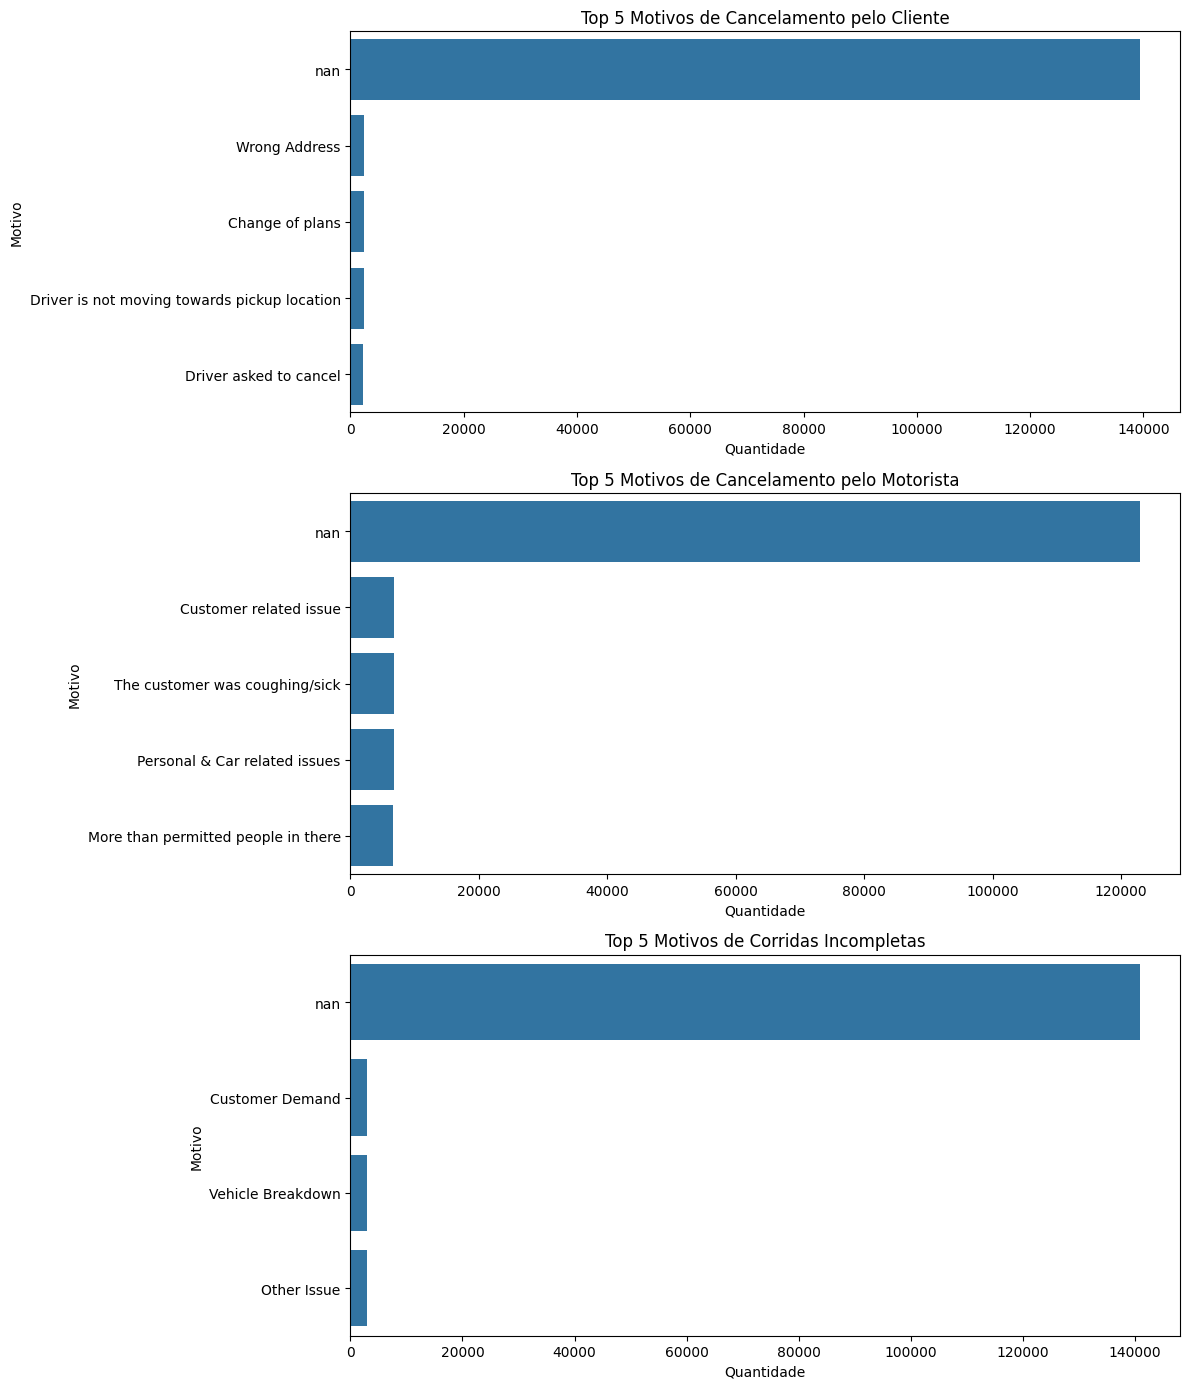

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
sns.countplot(data=df_uber[df_uber['Reason for cancelling by Customer'].notna()],y='Reason for cancelling by Customer',order=df_uber['Reason for cancelling by Customer'].value_counts().head(5).index,ax=axes[0])
axes[0].set_title('Top 5 Motivos de Cancelamento pelo Cliente')
axes[0].set_xlabel('Quantidade')
axes[0].set_ylabel('Motivo')

sns.countplot(data=df_uber[df_uber['Driver Cancellation Reason'].notna()],y='Driver Cancellation Reason',order=df_uber['Driver Cancellation Reason'].value_counts().head(5).index,ax=axes[1])
axes[1].set_title('Top 5 Motivos de Cancelamento pelo Motorista')
axes[1].set_xlabel('Quantidade')
axes[1].set_ylabel('Motivo')

sns.countplot(data=df_uber[df_uber['Incomplete Rides Reason'].notna()],y='Incomplete Rides Reason',order=df_uber['Incomplete Rides Reason'].value_counts().head(5).index,ax=axes[2])
axes[2].set_title('Top 5 Motivos de Corridas Incompletas')
axes[2].set_xlabel('Quantidade')
axes[2].set_ylabel('Motivo')

plt.tight_layout()
plt.show()

Observa-se que os valores ausentes (NaN) aparecem em grande quantidade porque essas colunas só são preenchidas quando o respectivo evento ocorre.

 Desconsiderando esses casos, é possível identificar razões recorrentes, como endereço incorreto, mudança de planos, problemas relacionados ao cliente, excesso de passageiros e falhas no veículo, evidenciando fatores relevantes que influenciam a não conclusão das corridas.




## Média e Distribuição das Avaliações


Nesta subseção, são analisadas as avaliações de motoristas e passageiros com o objetivo de compreender o comportamento geral dessas notas e verificar possíveis relações com eventos operacionais, como cancelamentos e corridas incompletas.





Inicialmente, é calculada a média das avaliações de motoristas e passageiros para comparar o comportamento geral dessas notas no dataset.



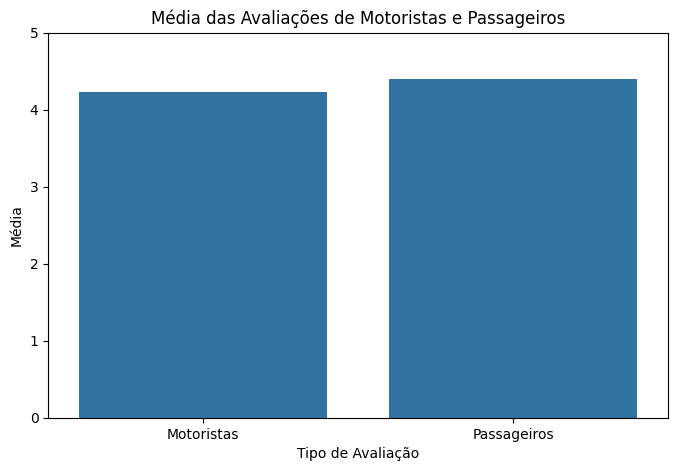

In [36]:
media_driver = df_uber['Driver Ratings'].mean()
media_customer = df_uber['Customer Rating'].mean()
medias_avaliacoes = pd.DataFrame({'tipo_avaliacao': ['Motoristas', 'Passageiros'],'media': [media_driver, media_customer]})
plt.figure(figsize=(8, 5))
sns.barplot(data=medias_avaliacoes, x='tipo_avaliacao', y='media')
plt.title('Média das Avaliações de Motoristas e Passageiros')
plt.xlabel('Tipo de Avaliação')
plt.ylabel('Média')
plt.ylim(0, 5)
plt.show()


O gráfico mostra que as médias das avaliações de motoristas e passageiros são bastante próximas e permanecem em níveis elevados. Observa-se uma leve superioridade na média das avaliações dos passageiros, indicando que, de forma geral, as notas registradas no dataset apontam para uma percepção positiva do serviço.



Em seguida, é utilizado um boxplot para observar a distribuição das avaliações, permitindo analisar mediana, dispersão e possíveis valores extremos.



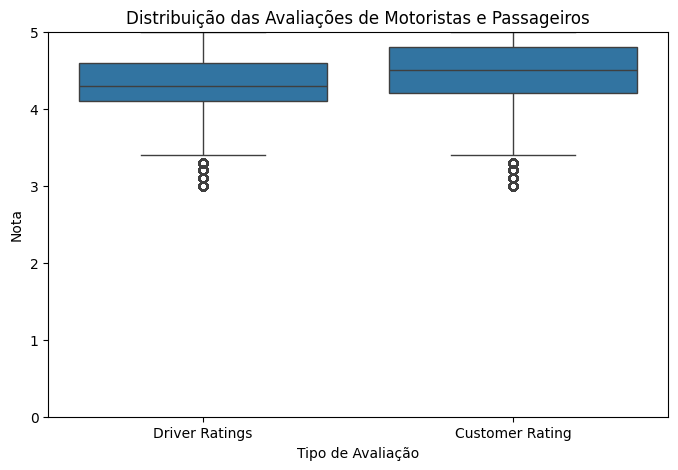

In [37]:
avaliacoes_boxplot = df_uber[['Driver Ratings', 'Customer Rating']].copy()
avaliacoes_boxplot = avaliacoes_boxplot.melt(var_name='tipo_avaliacao', value_name='nota')
plt.figure(figsize=(8, 5))
sns.boxplot(data=avaliacoes_boxplot, x='tipo_avaliacao', y='nota')
plt.title('Distribuição das Avaliações de Motoristas e Passageiros')
plt.xlabel('Tipo de Avaliação')
plt.ylabel('Nota')
plt.ylim(0, 5)
plt.show()

O boxplot complementa essa análise ao mostrar a distribuição das avaliações de motoristas e passageiros. Observa-se que as notas estão concentradas em valores altos, com mediana acima de 4 em ambos os casos, embora existam alguns valores mais baixos. Isso reforça a ideia de que a maior parte das avaliações registradas na base é positiva, com pouca variação entre os dois grupos.




## Correlação entre Variáveis Numéricas

É analisada a correlação entre as principais variáveis numéricas do dataset, com o objetivo de identificar possíveis associações lineares entre tempos médios, valor da corrida, distância e avaliações. Essa análise é útil para compreender como essas variáveis se relacionam e quais delas apresentam comportamento mais próximo entre si.



Para realizar essa análise, é criada inicialmente uma variável com a média das avaliações de motoristas e passageiros. Em seguida, é calculada a matriz de correlação entre variáveis numéricas relevantes da base, permitindo visualizar a intensidade e a direção das relações entre elas.



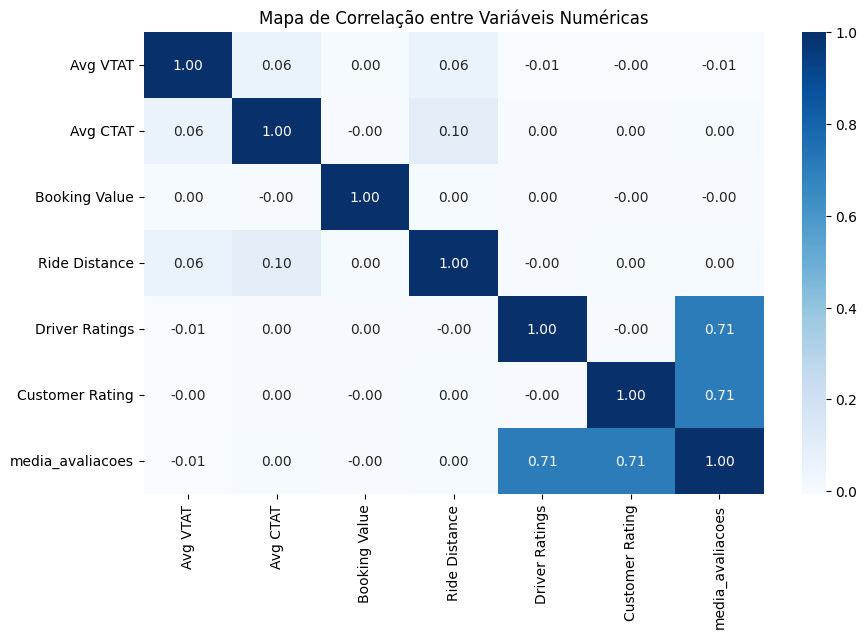

In [38]:
df_uber['media_avaliacoes'] = df_uber[['Driver Ratings', 'Customer Rating']].mean(axis=1)
colunas_corr = ['Avg VTAT','Avg CTAT','Booking Value','Ride Distance','Driver Ratings','Customer Rating','media_avaliacoes']
corr = df_uber[colunas_corr].corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Mapa de Correlação entre Variáveis Numéricas')
plt.show()

O mapa de correlação mostra que, de forma geral, as variáveis numéricas do dataset apresentam correlações fracas entre si, indicando baixa relação linear entre tempos médios, valor da corrida e distância.

A principal associação observada ocorre entre Driver Ratings, Customer Rating e media_avaliacoes, o que é esperado, já que a média foi construída a partir dessas duas variáveis.

Assim, o gráfico sugere que a maior parte das variáveis analisadas se comporta de maneira relativamente independente.

# Principais Insights

Nesta seção, são apresentados indicadores sintéticos derivados da análise exploratória, com o objetivo de resumir os principais padrões observados no dataset e destacar as informações mais relevantes para interpretação dos resultados.






## Resumo Quantitativo dos Principais Resultados

Inicialmente, são calculadas métricas gerais relacionadas ao volume de corridas, taxas operacionais, status mais frequente, horário de maior movimento e rotas mais recorrentes observadas na base.



In [39]:
total_corridas = len(df_uber)
taxa_conclusao = (df_uber['Booking Status'] == 'Completed').mean() * 100
taxa_cancelamento = ((df_uber['Cancelled Rides by Customer'] == 1) | (df_uber['Cancelled Rides by Driver'] == 1)).mean() * 100
taxa_corrida_incompleta = (df_uber['Incomplete Rides'] == 1).mean() * 100
status_mais_comum = df_uber['Booking Status'].mode()[0]
status_mais_comum = 'Concluída' if status_mais_comum == 'Completed' else status_mais_comum
hora_mais_movimentada = df_uber['hora'].mode()[0]
df_uber['rota'] = df_uber['Pickup Location'] + ' -> ' + df_uber['Drop Location']
top_rotas = df_uber['rota'].value_counts().head(5)
resumo_insights = pd.DataFrame({'indicador': [
        'Total de corridas','Taxa de conclusão (%)','Taxa de cancelamento (%)','Taxa de corridas incompletas (%)','Status mais frequente','Horário com mais corridas'],
    'valor': [total_corridas,
        round(taxa_conclusao, 2),
        round(taxa_cancelamento, 2),
        round(taxa_corrida_incompleta, 2),
        status_mais_comum,
        hora_mais_movimentada]})
display(resumo_insights)
print('Top 5 rotas mais frequentes:')
display(top_rotas.reset_index(name='quantidade'))


,indicador,valor
0,Total de corridas,150000
1,Taxa de conclusão (%),62.0
2,Taxa de cancelamento (%),25.0
3,Taxa de corridas incompletas (%),6.0
4,Status mais frequente,Concluída
5,Horário com mais corridas,18


Top 5 rotas mais frequentes:


,rota,quantidade
0,DLF City Court -> Bhiwadi,17
1,Akshardham -> RK Puram,16
2,Janakpuri -> Faridabad Sector 15,16
3,Jor Bagh -> Rohini East,15
4,Vatika Chowk -> Rithala,15


## Interpretação dos Resultados

A partir dessas métricas, é possível destacar alguns pontos importantes sobre o comportamento da base analisada:

- A taxa de conclusão indica que a maior parte das corridas registradas foi finalizada com sucesso;
- A taxa de cancelamento mostra que os cancelamentos representam uma parcela relevante da operação e merecem atenção analítica;
- As corridas incompletas aparecem em menor proporção, mas ainda representam um grupo importante para compreensão de falhas no processo;
- O horário com maior volume de corridas sugere um pico de demanda concentrado no início da noite;
- As rotas mais frequentes apresentam baixa repetição absoluta, indicando que os deslocamentos do dataset são relativamente pulverizados geograficamente.




De forma geral, os resultados mostram que o dataset apresenta padrões consistentes em relação ao comportamento das corridas, aos horários de maior movimento e aos principais eventos operacionais. Esses insights reforçam o potencial da base tanto para análises descritivas quanto para aplicações futuras em inteligência artificial, especialmente em tarefas de previsão e segmentação.

# Possíveis Aplicações em IA

Embora a proposta principal deste trabalho esteja centrada na análise exploratória e na compreensão do dataset, também foi incluída uma etapa complementar com possíveis aplicações em inteligência artificial. Essa parte foi desenvolvida como um acréscimo ao estudo, com o objetivo de demonstrar o potencial da base para tarefas mais avançadas de ciência de dados.

A inclusão dessa seção permite mostrar que, além de gerar insights descritivos, o dataset também pode ser utilizado em problemas de previsão e segmentação. Assim, os modelos apresentados devem ser entendidos como uma extensão analítica do trabalho, agregando valor à avaliação e evidenciando possibilidades práticas de uso dos dados em contextos reais.


## Modelos Supervisionados


Como extensão da análise, foram testados modelos supervisionados com o objetivo de verificar se o dataset apresenta potencial para tarefas de previsão. Esse tipo de abordagem é útil quando existe uma variável-alvo bem definida, permitindo que o algoritmo aprenda padrões a partir de exemplos históricos para realizar classificações ou estimativas em novos dados.


### Definição do Problema de Classificação

Nesta etapa, é definida como variável-alvo a condição de a corrida ser concluída ou não concluída.

Para isso, a coluna Booking Status foi transformada em uma variável binária, em que 1 representa corridas concluídas e 0 representa corridas não concluídas. Em seguida, são selecionadas variáveis explicativas relevantes para a modelagem.



In [40]:
df_sup = df_uber.copy()
df_sup['status_binario'] = df_sup['Booking Status'].apply(
    lambda x: 1 if str(x).strip().lower() == 'completed' else 0)
features_supervisionadas = [
    'Pickup Location',
    'Drop Location',
    'Avg VTAT',
    'Avg CTAT',
    'Cancelled Rides by Customer',
    'Cancelled Rides by Driver',
    'Incomplete Rides',
    'Booking Value',
    'Ride Distance',
    'Driver Ratings',
    'Customer Rating',
    'Payment Method',
    'hora',
    'dia_semana']
target = 'status_binario'
df_sup = df_sup[features_supervisionadas + [target]].copy()
df_sup = df_sup.dropna(subset=[target])
limite_modelagem = min(30000, len(df_sup))
df_sup = df_sup.sample(n=limite_modelagem, random_state=42)
X = df_sup[features_supervisionadas]
y = df_sup[target]

### Separação entre Treino e Teste
Após a definição das variáveis, os dados são divididos em conjuntos de treino e teste. Essa separação é importante para avaliar o desempenho dos modelos em dados não vistos anteriormente, reduzindo o risco de conclusões enviesadas.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Pré-processamento das Variáveis
Como a base possui variáveis numéricas e categóricas, é necessário montar um pipeline de pré-processamento. As variáveis numéricas passam por imputação da mediana e padronização, enquanto as variáveis categóricas passam por imputação do valor mais frequente e codificação one-hot.

In [42]:
cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
preprocessador = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)])

### Treinamento dos Modelos
Nesta etapa, são testados dois modelos supervisionados de classificação: Regressão Logística e Random Forest.

A escolha desses algoritmos permite comparar uma abordagem estatística mais simples com uma abordagem baseada em árvores de decisão, geralmente mais flexível para capturar padrões complexos.

In [43]:
modelos_supervisionados = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='saga'),
    'Random Forest': RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1, max_depth=16)}
resultados_supervisionados = []
predicoes = {}
for nome_modelo, modelo in modelos_supervisionados.items():
    pipeline = Pipeline(steps=[
        ('preprocessamento', preprocessador),
        ('modelo', modelo)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados_supervisionados.append({'modelo': nome_modelo,'accuracy': acc})
    predicoes[nome_modelo] = y_pred
resultados_supervisionados = pd.DataFrame(resultados_supervisionados).sort_values('accuracy', ascending=False)
display(resultados_supervisionados)

,modelo,accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


Os resultados iniciais mostram que ambos os modelos supervisionados apresentaram desempenho máximo em termos de acurácia no conjunto de teste. Tanto a Regressão Logística quanto o Random Forest alcançaram valor igual a 1,00, indicando capacidade total de classificação dentro da configuração utilizada.

### Avaliação do Melhor Modelo
Após a comparação inicial, é selecionado o modelo com melhor desempenho em acurácia.

Em seguida, são analisados o relatório de classificação e a matriz de confusão para entender com mais detalhe o comportamento preditivo do modelo escolhido.

Melhor modelo supervisionado (por accuracy): Logistic Regression

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2272
           1       1.00      1.00      1.00      3728

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



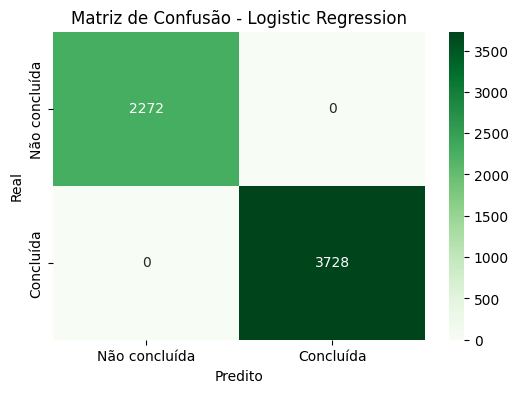

In [44]:
melhor_modelo = resultados_supervisionados.iloc[0]['modelo']
print(f'Melhor modelo supervisionado (por accuracy): {melhor_modelo}')
print('\nRelatório de classificação:')
print(classification_report(y_test, predicoes[melhor_modelo]))
cm = confusion_matrix(y_test, predicoes[melhor_modelo])
plt.figure(figsize=(6, 4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',
    xticklabels=['Não concluída', 'Concluída'],
    yticklabels=['Não concluída', 'Concluída'])
plt.title(f'Matriz de Confusão - {melhor_modelo}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

O relatório de classificação confirma o desempenho perfeito do modelo selecionado, com valores de precisão, recall e f1-score iguais a 1,00 para as duas classes analisadas. Isso indica que o modelo conseguiu identificar corretamente tanto as corridas concluídas quanto as não concluídas no conjunto de teste.

A matriz de confusão mostra que não houve erros de classificação, ou seja, todas as observações foram corretamente previstas pelo modelo.

Apesar do excelente resultado, esse desempenho deve ser interpretado com cautela, pois resultados perfeitos podem indicar que algumas variáveis utilizadas na modelagem possuem relação muito direta com a variável-alvo, tornando a previsão excessivamente facilitada.

### Considerações finais - Modelos Supervisionados
De forma geral, os modelos supervisionados mostram que o dataset possui potencial para aplicações preditivas, especialmente na tarefa de classificação de corridas concluídas e não concluídas.

Essa abordagem funciona como um complemento à análise exploratória, demonstrando que a base também pode ser utilizada em cenários de previsão operacional.

## Modelos Não Supervisionados

Além dos modelos supervisionados, também foi explorada uma abordagem não supervisionada, voltada para a identificação de padrões ocultos e segmentação dos registros.

Esse tipo de técnica é especialmente relevante quando o objetivo não é prever uma variável específica, mas descobrir agrupamentos naturais e perfis semelhantes dentro da base de dados.


### Preparação dos Dados para Clusterização
Nesta etapa, são selecionadas variáveis numéricas e categóricas consideradas relevantes para a segmentação das corridas.

 Como a clusterização é sensível à escala e à presença de diferentes tipos de dados, é necessário realizar um pré-processamento adequado antes da aplicação do algoritmo.

In [45]:
df_unsup = df_uber.copy()
features_unsup = [
    'Pickup Location',
    'Drop Location',
    'Payment Method',
    'Avg VTAT',
    'Avg CTAT',
    'Booking Value',
    'Ride Distance',
    'Driver Ratings',
    'Customer Rating',
    'hora',
    'dia_semana']
X_unsup = df_unsup[features_unsup].copy()
limite_cluster = min(20000, len(X_unsup))
df_unsup = df_unsup.sample(n=limite_cluster, random_state=42).copy()
X_unsup = df_unsup[features_unsup].copy()

### Pré-processamento das Variáveis
Em seguida, é construído um pipeline de pré-processamento para tratar separadamente as variáveis numéricas e categóricas.

As variáveis numéricas passam por imputação da mediana e padronização, enquanto as variáveis categóricas são imputadas com o valor mais frequente e transformadas com codificação one-hot.

In [46]:
cat_unsup = X_unsup.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_unsup = X_unsup.select_dtypes(include=[np.number, 'bool']).columns.tolist()
preprocessador_unsup = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())]), num_unsup),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_unsup)])
X_unsup_proc = preprocessador_unsup.fit_transform(X_unsup)

### Definição do Número de Clusters
Para determinar o número mais adequado de agrupamentos, é utilizado o silhouette score, métrica que avalia o grau de separação entre os clusters.

São testados diferentes valores de k, buscando identificar a configuração com melhor desempenho.

In [47]:
avaliacao_clusters = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_unsup_proc)
    amostra_silhouette = min(5000, X_unsup_proc.shape[0])
    score = silhouette_score(X_unsup_proc, labels, sample_size=amostra_silhouette, random_state=42)
    avaliacao_clusters.append({'k': k, 'silhouette': score})
avaliacao_clusters = pd.DataFrame(avaliacao_clusters)
display(avaliacao_clusters)
melhor_k = int(avaliacao_clusters.sort_values('silhouette', ascending=False).iloc[0]['k'])
print(f'Melhor número de clusters segundo silhouette score: {melhor_k}')

,k,silhouette
0,2,0.126994
1,3,0.125806
2,4,0.077913
3,5,0.079049
4,6,0.083754


Melhor número de clusters segundo silhouette score: 2


A análise do silhouette score mostrou que a configuração com 2 clusters apresentou o melhor desempenho entre os valores testados. No entanto, os scores obtidos foram baixos, o que sugere que a separação entre os grupos não é muito forte.

Ainda assim, a escolha de k = 2 representa a melhor solução comparativa dentro das variáveis e do pré-processamento adotados.

### Aplicação do Modelo Final
Após a escolha do número ideal de clusters, é ajustado o modelo final de KMeans.

Em seguida, os rótulos gerados são incorporados ao dataframe para permitir a análise do perfil médio de cada grupo.

In [48]:
kmeans_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
df_unsup['cluster'] = kmeans_final.fit_predict(X_unsup_proc)
perfil_clusters = df_unsup.groupby('cluster')[['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'hora']].mean().round(2)
display(perfil_clusters)

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,hora
cluster,,,,,
0,8.38,29.30,620.15,24.38,14.04
1,8.51,29.35,440.01,24.60,13.99


A análise do perfil médio dos clusters mostra que os grupos formados pelo KMeans são bastante semelhantes em relação aos tempos médios, distância percorrida e horário das corridas.

A principal diferença entre eles está no valor médio da corrida, sugerindo que a segmentação encontrada separa, principalmente, corridas de menor e maior valor.

### Visualização da Distribuição dos Status por Cluster
Para complementar a análise, é investigada a distribuição dos status das corridas dentro de cada cluster.

Essa visualização ajuda a entender se determinados grupos apresentam maior concentração de corridas concluídas, canceladas ou incompletas.

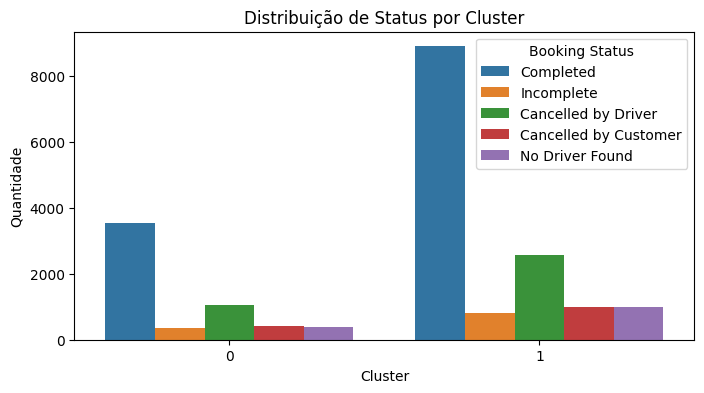

In [49]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_unsup, x='cluster', hue='Booking Status')
plt.title('Distribuição de Status por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Quantidade')
plt.show()

A distribuição dos status por cluster indica que os dois grupos mantêm predominância de corridas concluídas, mas com diferenças de volume entre eles.

 O cluster 1 reúne mais observações em praticamente todos os status, sugerindo um grupo mais numeroso e operacionalmente mais heterogêneo, enquanto o cluster 0 apresenta menor volume geral de corridas.

### Considerações finais - Modelos Não Supervisionados
De forma geral, a aplicação do KMeans mostrou que o dataset possui potencial para segmentação não supervisionada, permitindo identificar agrupamentos com características distintas. Essa abordagem complementa a análise exploratória ao revelar padrões que não dependem diretamente de uma variável-alvo pré-definida.




# **Conclusão do Estudo**

A análise do dataset ncr_ride_bookings.csv permitiu compreender de forma ampla o comportamento das corridas, desde a estrutura inicial da base até a identificação de padrões operacionais, temporais e financeiros.

Ao longo do estudo, foram realizadas etapas de limpeza, correção de inconsistências, criação de novas variáveis e análise exploratória, o que possibilitou uma visão mais clara, confiável e estruturada dos dados.

Os resultados mostraram que o conjunto de dados possui potencial significativo para apoiar tanto análises descritivas quanto aplicações em inteligência artificial.

Mesmo antes da modelagem, foi possível identificar padrões importantes relacionados à conclusão das corridas, cancelamentos, corridas incompletas, horários de maior movimento, avaliações, tempos médios e rotas mais frequentes, evidenciando oportunidades de uso estratégico dessas informações.

Além disso, a etapa de modelagem indicou que o dataset pode ser explorado tanto por abordagens supervisionadas, voltadas para a previsão de eventos, quanto por abordagens não supervisionadas, voltadas para segmentação e descoberta de perfis.

De forma geral, o estudo evidencia que a combinação entre análise exploratória, tratamento adequado dos dados e uso de inteligência artificial pode contribuir para melhorar a eficiência operacional, a experiência do usuário e a tomada de decisão orientada por dados.